## Cálculo de WER

In [1]:
from tools.wer_utils import calculate_wer_from_dataframe
import pandas as pd

full_df = pd.read_csv('dataset_normalized.csv')
wer, df_wer = calculate_wer_from_dataframe(full_df, 'ground_truth.json')
print(f"Global WER: {wer}")
df_wer.to_csv('dataset_wer.csv', index=False)

Global WER: 0.07237244897959183


In [10]:
# --- Tabla Resumen: WER Global por Proveedor ---
import pandas as pd

if 'df_wer' in locals():
    # Agrupar por proveedor y sumar errores y palabras de referencia
    summary_wer = df_wer.groupby('provider').agg(
        Total_Errores=('errors', 'sum'),
        Total_Palabras=('reference_words', 'sum')
    ).reset_index()
    
    # Calcular WER (Micro-average)
    summary_wer['WER'] = summary_wer['Total_Errores'] / summary_wer['Total_Palabras']
    
    # Renombrar columna y ordenar
    summary_wer = summary_wer.rename(columns={'provider': 'ASR'})
    summary_wer = summary_wer[['ASR', 'WER', 'Total_Errores', 'Total_Palabras']].sort_values('WER')
    
    # Mostrar tabla formateada
    print("Resumen de WER Global por Proveedor:")
    display(summary_wer.style.format({
        'WER': '{:.2%}',
        'Total_Errores': '{:.0f}',
        'Total_Palabras': '{:.0f}'
    }).hide(axis='index').set_properties(**{
        'text-align': 'center', 
        'padding': '8px'
    }).set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
    ]))
else:
    print("Error: 'df_wer' no está definido. Asegúrate de ejecutar las celdas anteriores.")

Resumen de WER Global por Proveedor:


ASR,WER,Total_Errores,Total_Palabras
google,5.29%,1036,19600
whisper,6.78%,1329,19600
azure,8.42%,1650,19600
amazon,8.46%,1659,19600


In [2]:
display(df_wer.head())

,person,audio,noise,snr,provider,text,status,transcription_time,text_normalized,reference,wer,errors,reference_words,substitutions,deletions,insertions
0,p7,1,cafe,0dB,whisper,Genera una cotización para el cliente con fáci...,success,1.65,genera una cotización para el cliente con fáci...,genera una cotización para el cliente compufac...,0.1250,2.0,16.0,1.0,0.0,1.0
1,p7,1,cafe,5dB,whisper,Genera una cotización para el cliente con PUC ...,success,1.56,genera una cotización para el cliente con puc ...,genera una cotización para el cliente compufac...,0.1875,3.0,16.0,1.0,0.0,2.0
2,p7,1,cafe,10dB,whisper,Genera una cotización para el cliente con Puff...,success,1.59,genera una cotización para el cliente con puff...,genera una cotización para el cliente compufac...,0.1250,2.0,16.0,1.0,0.0,1.0
3,p7,1,clean,clean,whisper,Genera una cotización para el cliente con FooF...,success,1.66,genera una cotización para el cliente con foof...,genera una cotización para el cliente compufac...,0.1250,2.0,16.0,1.0,0.0,1.0
4,p7,1,traffic,0dB,whisper,"genera una cotización para el cliente fácil, c...",success,1.53,genera una cotización para el cliente fácil co...,genera una cotización para el cliente compufac...,0.3750,6.0,16.0,6.0,0.0,0.0


Calculando WER Global e Intervalos de Confianza...
Realizando pruebas estadísticas...
Tabla Comparativa: Rendimiento Global con Intervalos de Confianza


Motor,WER Global,IC 95% Inf,IC 95% Sup
google,5.29%,4.68%,5.93%
whisper,6.78%,6.21%,7.41%
azure,8.42%,7.85%,9.06%
amazon,8.46%,7.82%,9.11%


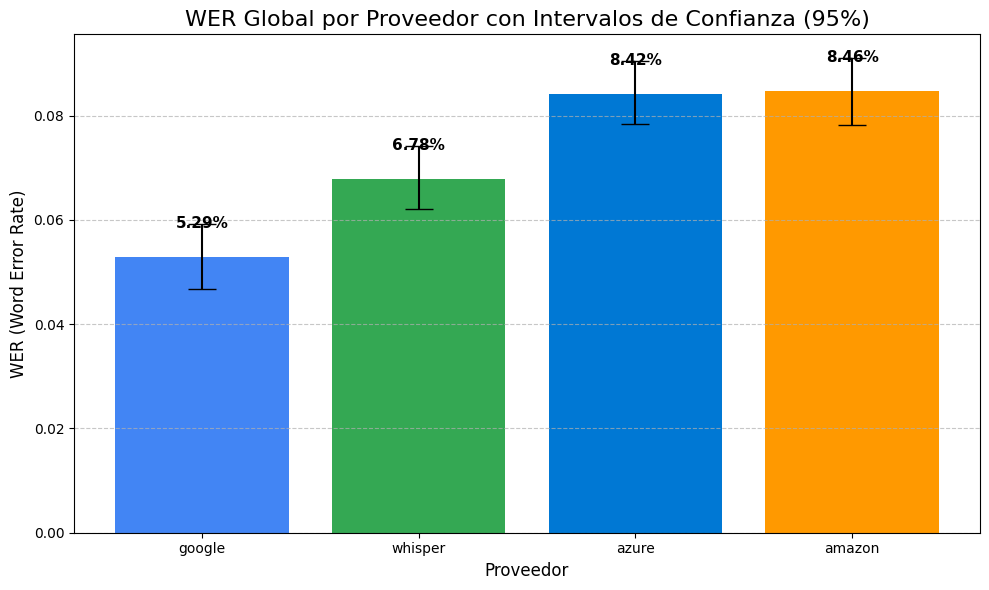


 Análisis Estadístico de Significancia 
Test de Friedman: Estadístico=334.5658, p-value=3.2767e-72
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Bonferroni)...


,Comparación,p-value original,p-value adj (Bonferroni),Significativo
0,amazon vs azure,1.237132e-02,7.422793e-02,False
1,amazon vs google,1.143916e-26,6.863499e-26,True
2,amazon vs whisper,8.363424e-07,5.018054e-06,True
3,azure vs google,6.388845e-38,3.833307e-37,True
4,azure vs whisper,1.963362e-13,1.178017e-12,True
5,google vs whisper,2.206342e-14,1.323805e-13,True


In [3]:
# --- Refactorización: Uso de Clases para Análisis y Visualización (WER Global) ---
import sys
import os
sys.path.append(os.getcwd())
from tools.wer_analysis import WERAnalyzer, WERVisualizer

# 1. Análisis de Datos
if 'df_wer' in locals():
    analyzer = WERAnalyzer(df_wer)
    
    # 1.1 Calcular WER Global con Intervalos de Confianza
    print("Calculando WER Global e Intervalos de Confianza...")
    global_wer_df = analyzer.calculate_global_wer()
    
    # 1.2 Análisis Estadístico
    print("Realizando pruebas estadísticas...")
    friedman_res, wilcoxon_df = analyzer.perform_statistical_tests()

    # 2. Visualización
    visualizer = WERVisualizer()
    
    # 2.1 Tabla Comparativa Global
    display(visualizer.display_global_wer_table(global_wer_df))
    
    # 2.2 Gráfico de Barras Global
    visualizer.plot_global_wer(global_wer_df)
    
    # 2.3 Resultados Estadísticos
    visualizer.display_statistical_results(friedman_res, wilcoxon_df)

else:
    print("Error: 'df_wer' no está definido. Asegúrate de ejecutar las celdas anteriores.")

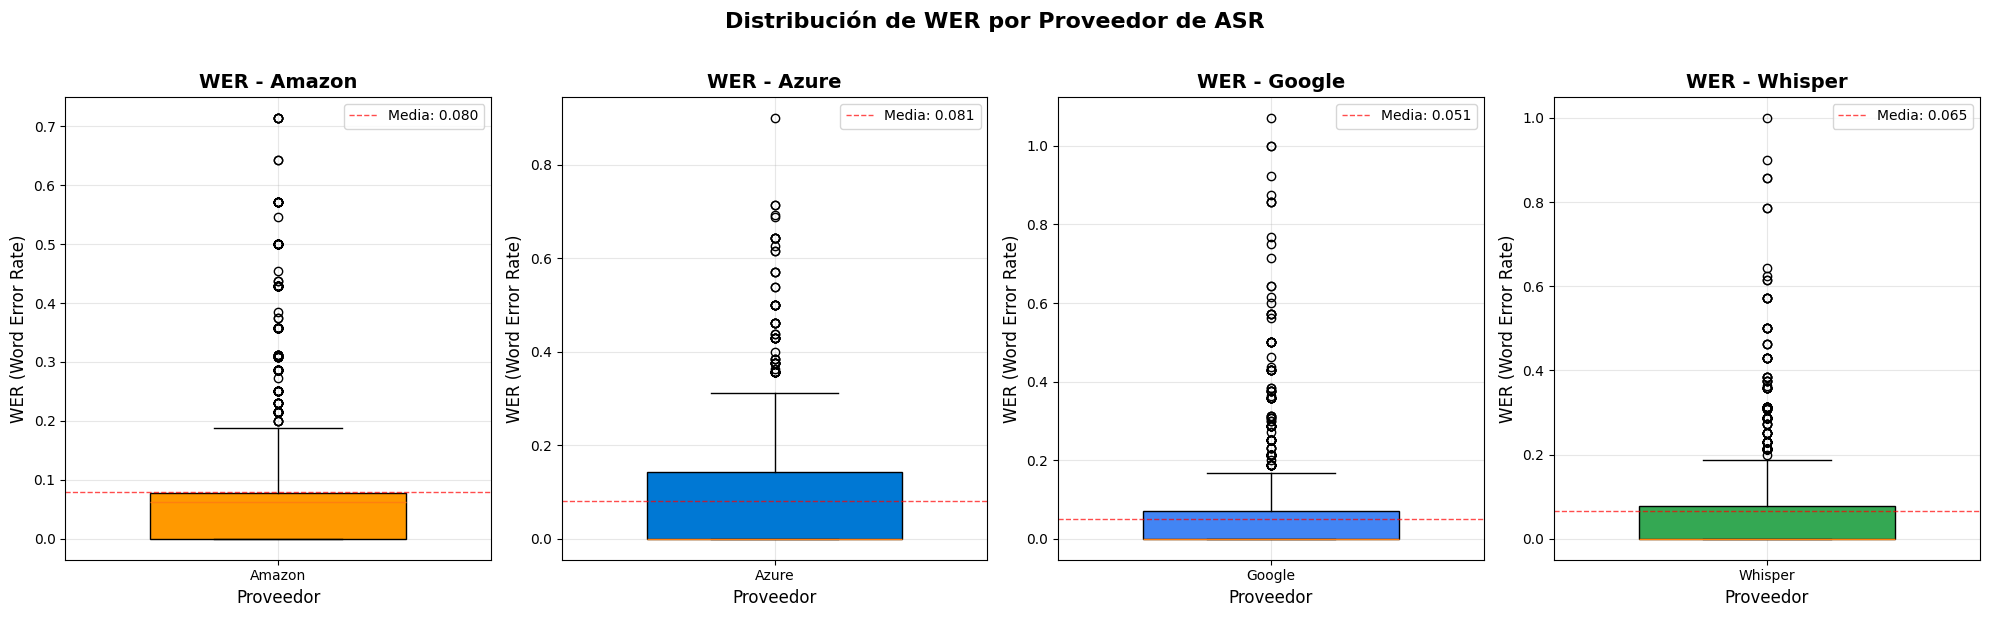


Estadísticas de WER por Proveedor:


Proveedor,Media,Mediana,Mínimo,Máximo,Desv. Est.,Muestras
Amazon,0.0796,0.0625,0.0000,0.7143,0.1243,1500
Azure,0.0809,0.0000,0.0000,0.9000,0.1196,1500
Google,0.0513,0.0000,0.0000,1.0714,0.1192,1500
Whisper,0.0647,0.0000,0.0000,1.0000,0.1157,1500


In [4]:
# --- Gráfico de caja: Distribución de WER por proveedor ---
import sys
import os
sys.path.append(os.getcwd())
from tools.wer_analysis import WERVisualizer

if 'df_wer' in locals():
    visualizer = WERVisualizer()
    stats_df = visualizer.plot_wer_boxplot(df_wer, title='Distribución de WER por Proveedor de ASR', show_stats=True)
    if stats_df is not None:
        display(stats_df)
else:
    print("Error: 'df_wer' no está definido. Ejecuta las celdas anteriores.")

Calculando intervalos de confianza con bootstrap...


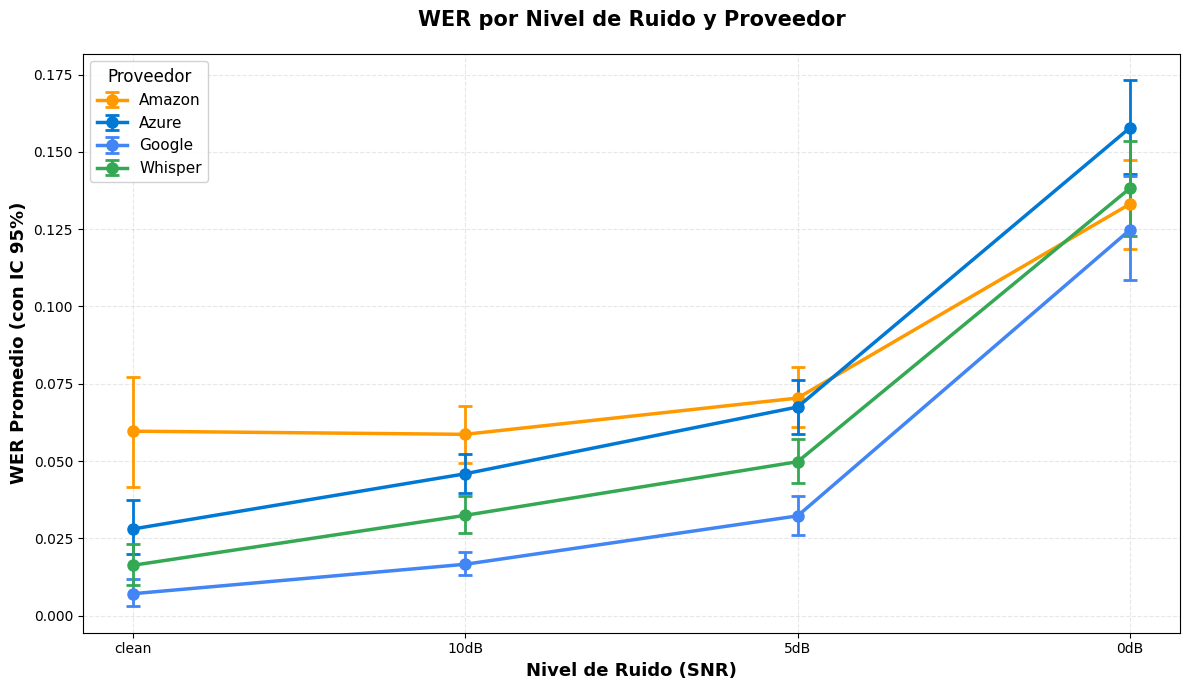


Tabla Comparativa de WER por Escenario y Degradación:


Motor,clean,10dB,5dB,0dB,Degradación (Delta)
amazon,5.97%,5.87%,7.04%,13.32%,+123.08%
azure,2.81%,4.59%,6.75%,15.78%,+462.42%
google,0.71%,1.67%,3.23%,12.48%,+1647.62%
whisper,1.63%,3.25%,4.98%,13.83%,+746.87%


In [5]:
# --- Refactorización: Uso de Clases para Análisis y Visualización ---
# Importamos las clases desde el módulo tools.wer_analysis
# Asegúrate de que el archivo tools/wer_analysis.py exista
import sys
import os
sys.path.append(os.getcwd())
from tools.wer_analysis import WERAnalyzer, WERVisualizer

# 1. Análisis de Datos
# Instanciamos el analizador con el DataFrame completo (df_wer)
# df_wer debe contener 'provider', 'snr', 'errors', 'reference_words'
if 'df_wer' in locals():
    analyzer = WERAnalyzer(df_wer)
    
    # Calculamos WER y CIs por proveedor y SNR
    print("Calculando intervalos de confianza con bootstrap...")
    wer_results = analyzer.calculate_wer_by_provider_snr()
    
    # 2. Visualización
    visualizer = WERVisualizer()
    
    # Generamos el gráfico
    visualizer.plot_wer_by_snr(wer_results)
    
    # Mostramos la tabla comparativa
    display(visualizer.display_comparative_table(wer_results))
    
    # Guardamos los resultados para uso posterior si es necesario
    wer_by_provider_snr = wer_results # Mantener compatibilidad con celdas posteriores
else:
    print("Error: 'df_wer' no está definido. Asegúrate de ejecutar las celdas anteriores.")

In [6]:
# --- Análisis Estadístico Específico para 0 dB ---
# Objetivo: Determinar si Google sigue siendo superior bajo estrés acústico extremo o si hay un empate técnico.

import sys
import os
sys.path.append(os.getcwd())
from tools.wer_analysis import WERAnalyzer, WERVisualizer

if 'df_wer' in locals():
    # 1. Instanciar Analizador
    analyzer = WERAnalyzer(df_wer)
    
    # 2. Filtrar datos para 0 dB
    print("Aislando transcripciones a 0 dB...")
    df_0db = analyzer.filter_by_snr('0dB')
    
    if not df_0db.empty:
        # 3. Realizar pruebas estadísticas (Friedman + Wilcoxon)
        print("Ejecutando pruebas estadísticas para el escenario de 0 dB...")
        friedman_res_0db, wilcoxon_df_0db = analyzer.perform_statistical_tests(df_0db)
        
        # 4. Visualizar Resultados
        visualizer = WERVisualizer()
        visualizer.display_statistical_results(friedman_res_0db, wilcoxon_df_0db, title="Análisis Estadístico de Significancia (Escenario 0 dB)")
        
        # 5. Mostrar WER Global en 0 dB (Micro-average CORRECTO)
        print("\nWER Global en 0 dB (Micro-average):")
        # Agrupamos y sumamos errores/palabras para calcular el WER real
        wer_0db_summary = df_0db.groupby('provider').agg(
            total_errors=('errors', 'sum'),
            total_words=('reference_words', 'sum')
        ).reset_index()
        wer_0db_summary['wer'] = wer_0db_summary['total_errors'] / wer_0db_summary['total_words']
        
        display(wer_0db_summary[['provider', 'wer']].sort_values('wer').style.format({'wer': '{:.2%}'}).hide(axis='index'))
    else:
        print("No se encontraron datos para el nivel de ruido '0dB'.")
else:
    print("Error: 'df_wer' no está definido. Asegúrate de ejecutar las celdas anteriores.")

Aislando transcripciones a 0 dB...
Ejecutando pruebas estadísticas para el escenario de 0 dB...

 Análisis Estadístico de Significancia (Escenario 0 dB) 
Test de Friedman: Estadístico=56.7052, p-value=2.9706e-12
>> Diferencias significativas encontradas. Realizando post-hoc (Wilcoxon + Bonferroni)...


,Comparación,p-value original,p-value adj (Bonferroni),Significativo
0,amazon vs azure,5.038496e-06,3.023097e-05,True
1,amazon vs google,2.721435e-01,1.000000e+00,False
2,amazon vs whisper,2.077283e-01,1.000000e+00,False
3,azure vs google,1.588402e-07,9.530410e-07,True
4,azure vs whisper,4.081270e-04,2.448762e-03,True
5,google vs whisper,4.066598e-03,2.439959e-02,True



WER Global en 0 dB (Micro-average):


provider,wer
google,12.48%
amazon,13.32%
whisper,13.83%
azure,15.78%


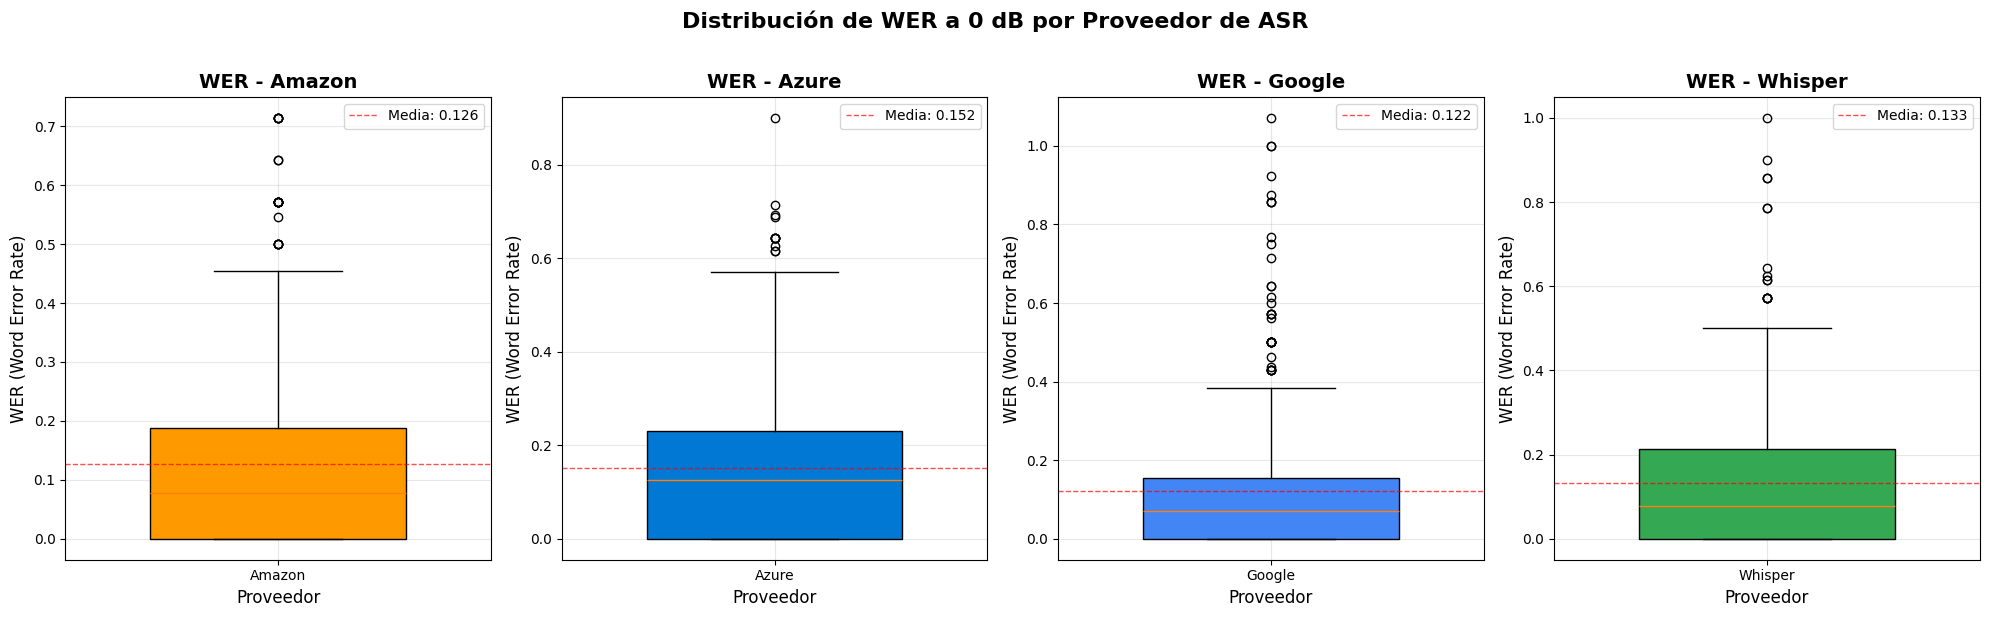


Estadísticas de WER por Proveedor:


Proveedor,Media,Mediana,Mínimo,Máximo,Desv. Est.,Muestras
Amazon,0.1261,0.0769,0.0000,0.7143,0.1542,450
Azure,0.1520,0.1250,0.0000,0.9000,0.1616,450
Google,0.1219,0.0714,0.0000,1.0714,0.1838,450
Whisper,0.1329,0.0769,0.0000,1.0000,0.1655,450


In [7]:
# --- Gráfico de caja: Distribución de WER a 0 dB ---
import sys
import os
sys.path.append(os.getcwd())
from tools.wer_analysis import WERAnalyzer, WERVisualizer

if 'df_wer' in locals():
    # 1. Instanciar Analizador y filtrar por 0 dB
    analyzer = WERAnalyzer(df_wer)
    df_0db = analyzer.filter_by_snr('0dB')
    
    if not df_0db.empty:
        # 2. Visualizar Boxplot para 0 dB
        visualizer = WERVisualizer()
        stats_df = visualizer.plot_wer_boxplot(
            df_0db, 
            title='Distribución de WER a 0 dB por Proveedor de ASR', 
            show_stats=True
        )
        if stats_df is not None:
            display(stats_df)
    else:
        print("No se encontraron datos para el nivel de ruido '0dB'.")
else:
    print("Error: 'df_wer' no está definido. Asegúrate de ejecutar las celdas anteriores.")

Recalculando WER con desglose de errores...


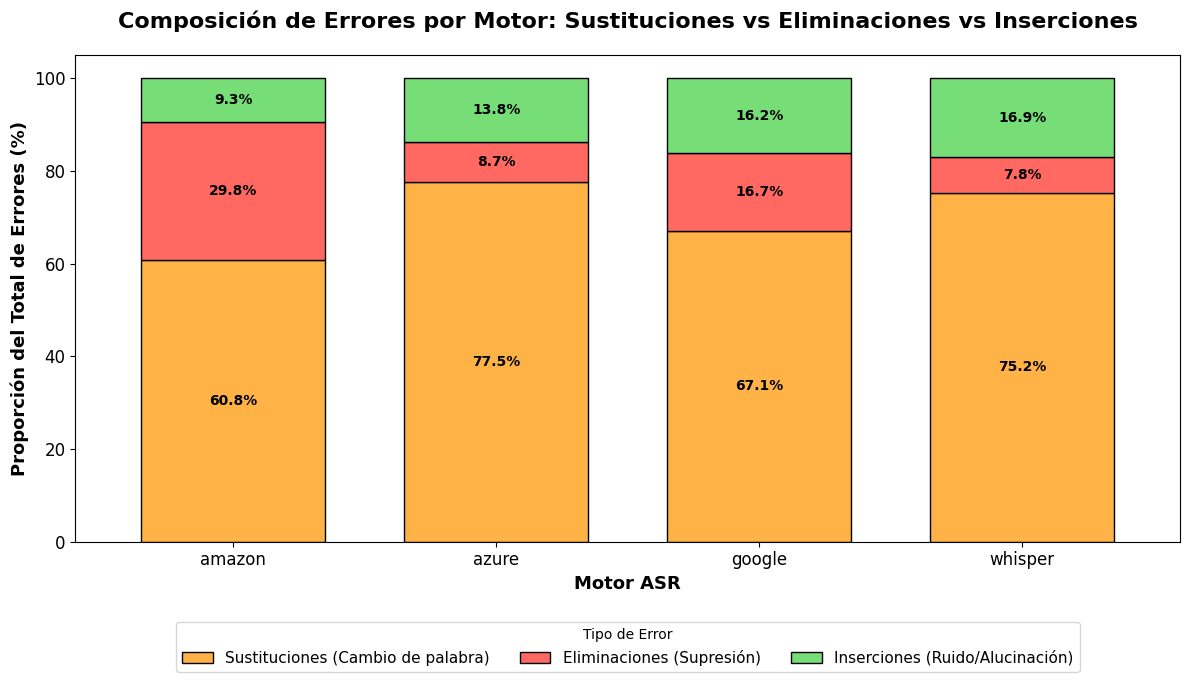


Desglose de Errores (Cantidad y Porcentaje):


,substitutions,deletions,insertions,substitutions (%),deletions (%),insertions (%)
provider,,,,,,
amazon,1009.000000,495.000000,155.000000,60.8,29.8,9.3
azure,1279.000000,144.000000,227.000000,77.5,8.7,13.8
google,695.000000,173.000000,168.000000,67.1,16.7,16.2
whisper,1000.000000,104.000000,225.000000,75.2,7.8,16.9


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from tools.wer_utils import calculate_wer_from_dataframe

print("Recalculando WER con desglose de errores...")
wer_global, df_detailed = calculate_wer_from_dataframe(full_df, 'ground_truth.json')

# 2. Agrupar por proveedor y sumar componentes de error
error_components = ['substitutions', 'deletions', 'insertions']
error_breakdown = df_detailed.groupby('provider')[error_components].sum()

# 3. Calcular porcentajes (Normalizar al 100% de los errores totales de cada proveedor)
error_breakdown['total_errors'] = error_breakdown.sum(axis=1)
error_breakdown_pct = error_breakdown[error_components].div(error_breakdown['total_errors'], axis=0) * 100

# 4. Graficar Barras Apiladas al 100%
ax = error_breakdown_pct.plot(kind='bar', stacked=True, figsize=(12, 7), 
                              color=['#FFB347', '#FF6961', '#77DD77'], # Naranja (S), Rojo (D), Verde (I)
                              edgecolor='black', width=0.7)

# Configuración del gráfico
plt.title('Composición de Errores por Motor: Sustituciones vs Eliminaciones vs Inserciones', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Motor ASR', fontsize=13, fontweight='bold')
plt.ylabel('Proporción del Total de Errores (%)', fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Configurar leyenda
plt.legend(title='Tipo de Error', labels=['Sustituciones (Cambio de palabra)', 'Eliminaciones (Supresión)', 'Inserciones (Ruido/Alucinación)'], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=11)

# Añadir etiquetas de porcentaje en el centro de las barras
for c in ax.containers:
    # Filtrar etiquetas para barras muy pequeñas
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla de datos absolutos y porcentuales
print("\nDesglose de Errores (Cantidad y Porcentaje):")
display(pd.concat([error_breakdown[error_components], error_breakdown_pct.add_suffix(' (%)')], axis=1).style.format("{:.1f}", subset=error_breakdown_pct.columns.map(lambda x: x + ' (%)')))

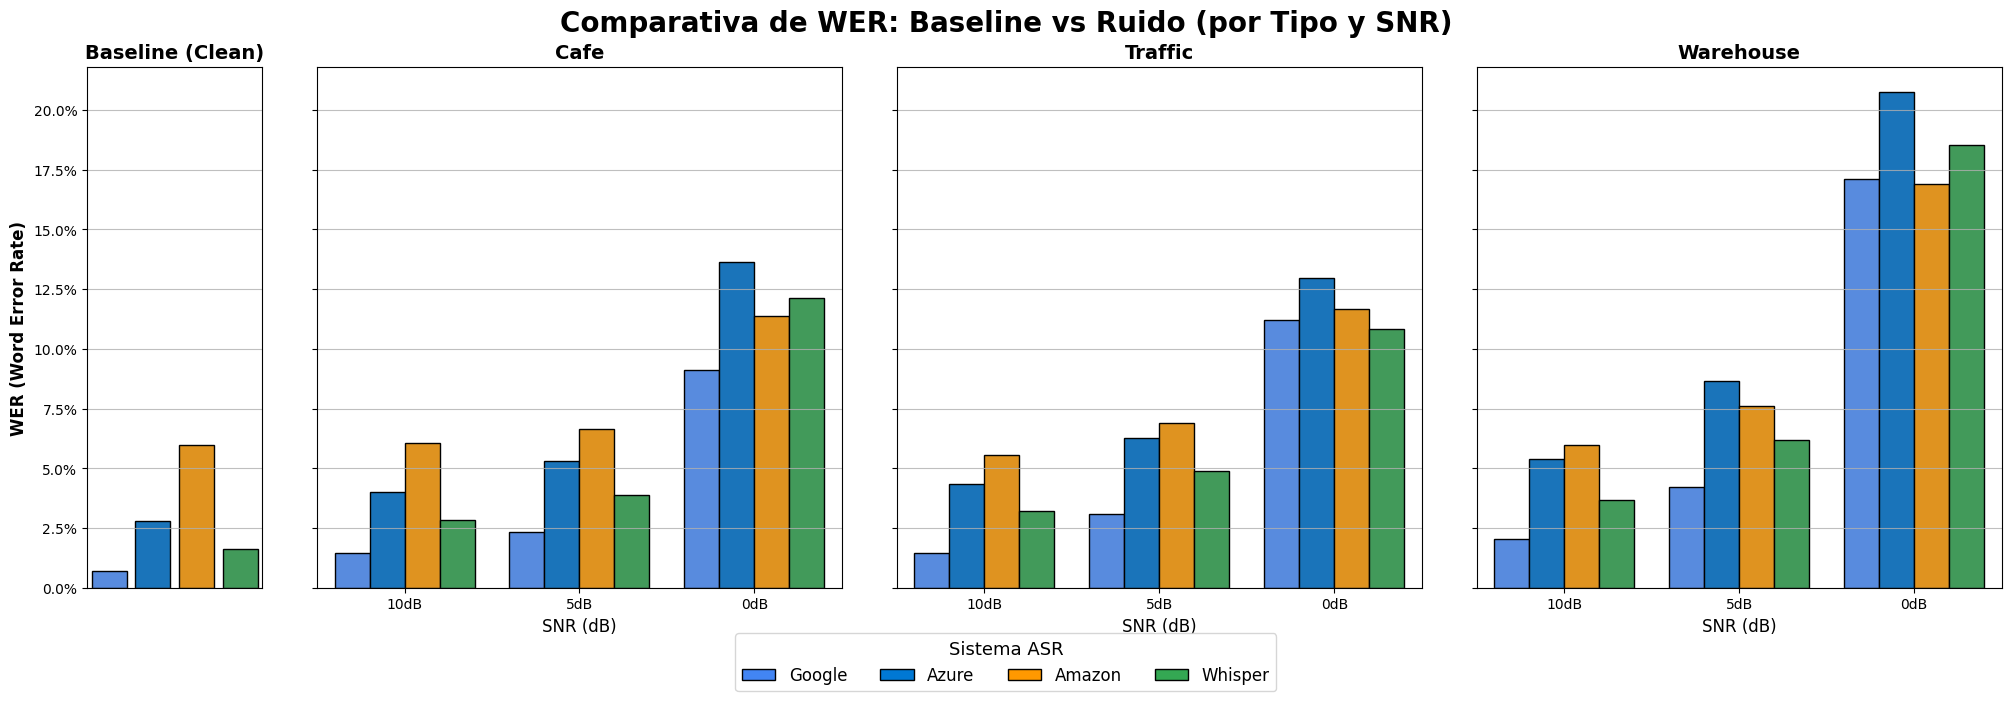

Tabla Resumen de WER por Ruido, SNR y Proveedor:


provider           amazon     azure    google   whisper
noise     snr                                          
cafe      0dB    0.113776  0.136224  0.091327  0.121429
          10dB   0.060714  0.040306  0.014796  0.028571
          5dB    0.066327  0.053061  0.023469  0.038776
clean     clean  0.059694  0.028061  0.007143  0.016327
traffic   0dB    0.116837  0.129592  0.112245  0.108163
          10dB   0.055612  0.043367  0.014796  0.032143
          5dB    0.068878  0.062755  0.031122  0.048980
warehouse 0dB    0.168878  0.207653  0.170918  0.185204
          10dB   0.059694  0.054082  0.020408  0.036735
          5dB    0.076020  0.086735  0.042347  0.061735

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

# 1. Preparar los datos unificados
# Agrupar por provider, noise y snr
unified_wer = df_wer.groupby(['provider', 'noise', 'snr']).agg(
    total_errors=('errors', 'sum'),
    total_reference_words=('reference_words', 'sum')
).reset_index()

# Calcular WER
unified_wer['wer'] = unified_wer['total_errors'] / unified_wer['total_reference_words']

# Configuración de estilos
providers = ['google', 'azure', 'amazon', 'whisper']
colors = {'google': '#4285F4', 'azure': '#0078D4', 'amazon': '#FF9900', 'whisper': '#34A853'}
snr_levels_noisy = ['10dB', '5dB', '0dB']
noises = sorted([n for n in unified_wer['noise'].unique() if n != 'clean'])

# Crear figura con GridSpec para diseño asimétrico
fig = plt.figure(figsize=(20, 6), layout='constrained')
gs = fig.add_gridspec(1, 4, width_ratios=[1, 3, 3, 3], wspace=0.1)

# --- 1. Panel Clean (Baseline) ---
ax_clean = fig.add_subplot(gs[0])
clean_data = unified_wer[unified_wer['noise'] == 'clean']

sns.barplot(data=clean_data, x='provider', y='wer', hue='provider', order=providers, palette=colors, ax=ax_clean, edgecolor='black', legend=False)

ax_clean.set_title("Baseline (Clean)", fontsize=14, fontweight='bold')
ax_clean.set_xlabel("")
ax_clean.set_ylabel("WER (Word Error Rate)", fontsize=12, fontweight='bold')
ax_clean.tick_params(axis='x', bottom=False, labelbottom=False) # Ocultar etiquetas x para limpieza

# --- 2. Paneles de Ruido ---
axes_noisy = []
for i, noise in enumerate(noises):
    ax = fig.add_subplot(gs[i+1], sharey=ax_clean)
    axes_noisy.append(ax)
    
    noise_data = unified_wer[unified_wer['noise'] == noise]
    
    sns.barplot(data=noise_data, x='snr', y='wer', hue='provider', 
                hue_order=providers, order=snr_levels_noisy, 
                palette=colors, ax=ax, edgecolor='black')
    
    ax.set_title(noise.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel("SNR (dB)", fontsize=12)
    ax.set_ylabel("")
    ax.get_legend().remove()

# --- 3. Ajustes Finales ---
# Formato porcentaje en eje Y
for ax in [ax_clean] + axes_noisy:
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(True, axis='y', linestyle='-', alpha=0.8, linewidth=0.8)

# Ocultar eje Y en gráficos de ruido
for ax in axes_noisy:
    plt.setp(ax.get_yticklabels(), visible=False)

# Título global
fig.suptitle('Comparativa de WER: Baseline vs Ruido (por Tipo y SNR)', fontsize=20, fontweight='bold', y=1.05)

# Leyenda única
legend_patches = [mpatches.Patch(facecolor=colors[p], label=p.capitalize(), edgecolor='black') for p in providers]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=12, title="Sistema ASR", title_fontsize=13)

plt.show()

# Mostrar tabla resumen opcional
print("Tabla Resumen de WER por Ruido, SNR y Proveedor:")
pivot_table = unified_wer.pivot_table(index=['noise', 'snr'], columns='provider', values='wer')
display(pivot_table)